In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy import units as u
from euclid_sbf_pipeline import MainPipeline

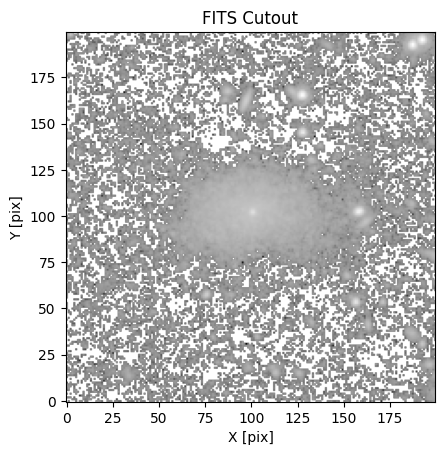

In [ ]:
# hdul= fits.open('Euclid/data/ERO-Dorado/Euclid-NISP-H-ERO-Dorado-Flattened.DR3.fits/Euclid-NISP-H-ERO-Dorado-Flattened.v3.fits')
# full_data = hdul[0].data
# full_header = hdul[0].header
# full_header
# wcs = WCS(full_header)
# cutout_size = 200

# ra_center, dec_center = ('04 14 09.024', '-55 42 27.23')
# position = SkyCoord(ra_center, dec_center, unit=(u.hourangle, u.deg), frame='icrs')
# cutout = Cutout2D(full_data, position, (cutout_size, cutout_size), wcs=wcs, copy=True)
# new_header = full_header.copy()
# new_header.update(cutout.wcs.to_header())
# hdu_cutout = fits.PrimaryHDU(data=cutout.data, header=new_header)
# hdu_cutout.writeto("Euclid/data/caviaH/flt/caviaH.fits", overwrite=True)

# fieldcutout = Cutout2D(full_data, position, (cutout_size*2, cutout_size*2), wcs=wcs, copy=True)
# new_header_field = full_header.copy()
# new_header_field.update(fieldcutout.wcs.to_header())

# hdu_fieldcutout = fits.PrimaryHDU(data=fieldcutout.data, header=new_header_field)
# hdu_fieldcutout.data[cutout_size//2:cutout_size*3//2, cutout_size//2:cutout_size*3//2] = np.nan ## FIXXXX
# hdu_fieldcutout.writeto("Euclid/data/caviaH/field_caviaH.fits", overwrite=True)


# plt.figure()
# plt.imshow(cutout.data, origin='lower', cmap='gray', norm='log')
# plt.xlabel('X [pix]')
# plt.ylabel('Y [pix]')
# plt.title('FITS Cutout')
# plt.show()

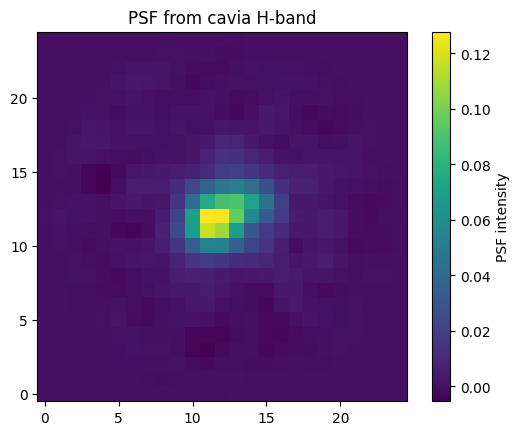

In [5]:
psf_data, psf_header = fits.getdata("psfex-sex-files-Hband/stars.psf", ext=1, header=True) 
plt.imshow(psf_data[0][0][0], origin="lower", cmap="viridis")
plt.colorbar(label=f"PSF intensity")
plt.title(f"PSF from cavia H-band")
plt.show()    
psf = psf_data[0][0][0]
psf = psf / np.sum(psf)  # Normalize the PSF


1. Extracting the data ...

2. No background estimation performed ...

3. Fitting initial ellipse model ...


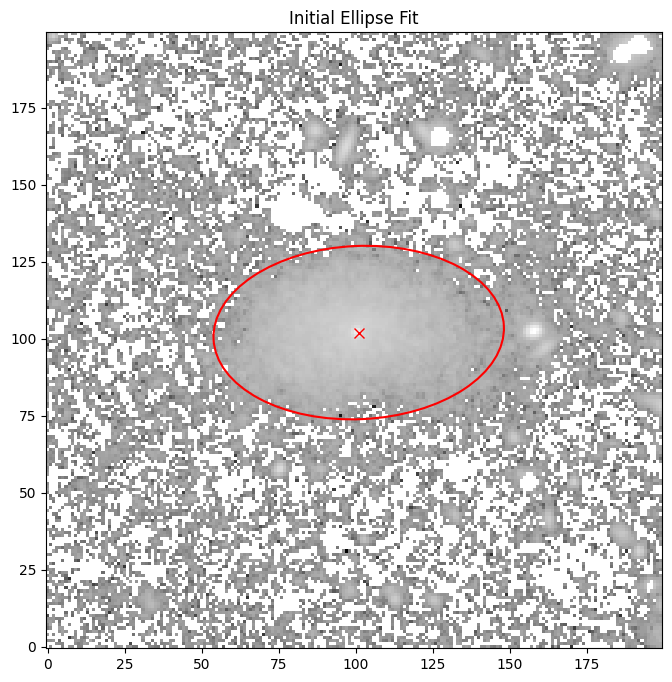

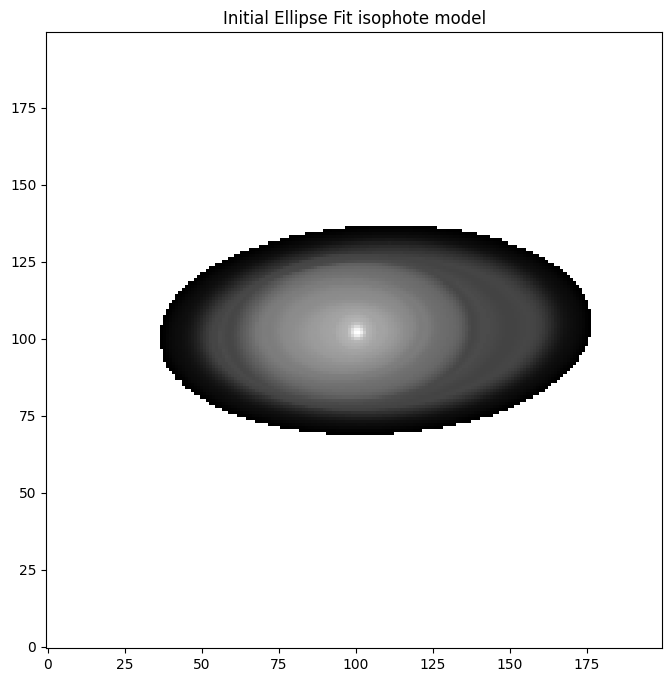

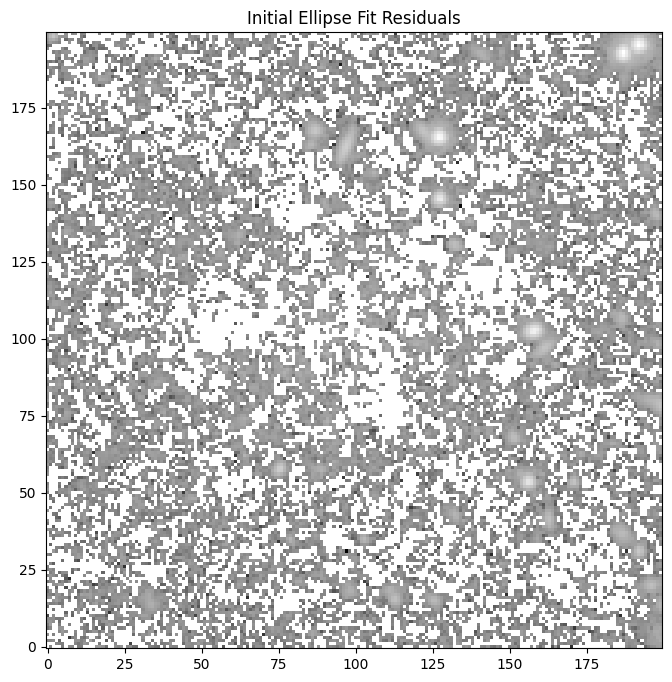


4. Finding initial source mask ...


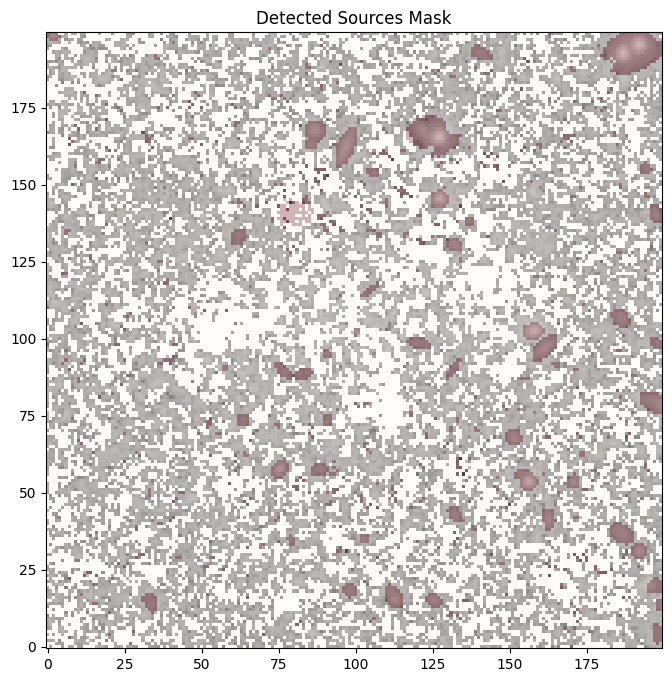


5. Fitting final ellipse model ...
Center pixel is masked — unmasking central area.


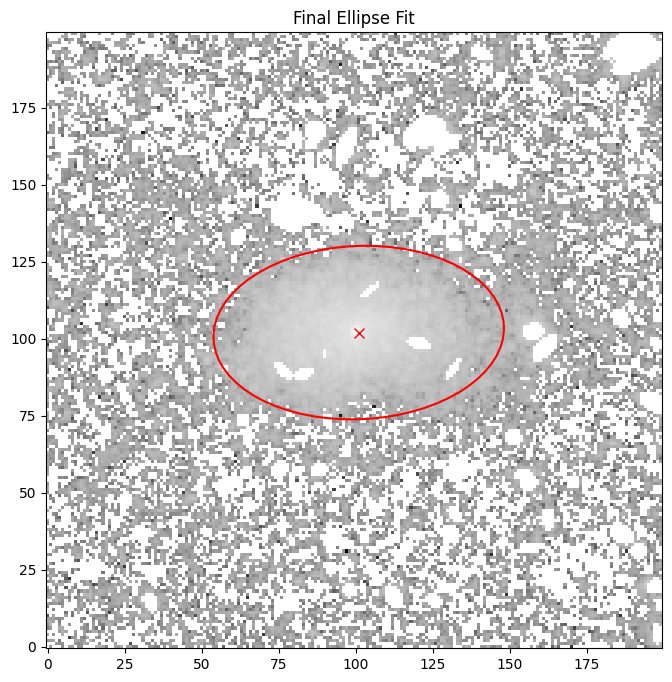

Trying larger step size for ellipse fitting...
Ellipse fitting failed


SystemExit: 

/root/MasterThesis/SBF_Pipeline/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [6]:
data_path = 'Euclid/data/caviaH/flt'
file_path = 'Euclid/data/caviaH/return_files'
image_path = 'Euclid/data/caviaH/images'

data, mask_model, mask_combined, nri, image_ps, expected_ps, sbf, noise, sbfmag = MainPipeline(data_path, image_path=image_path, make_plots=True, psf=psf, filter="H")

In [1]:
import numpy as np

In [2]:
sbfflux = np.array([22.590228143669357, 29.468008195922707, 5.917957315371727, 12.167760755733372])

I_H_A = 26.747198457555626 - 24.35792863944816
print("I-H color (AB mag):", I_H_A)

I-H color (AB mag): 2.389269818107465


In [3]:
dist = 5*np.log10(18) + 25
print(dist)

31.276362525516532
